<a href="https://colab.research.google.com/github/rmnmr13/SATAID_example/blob/main/Time_Series_Update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sataid
!pip install cartopy rasterio
import sataid as sat
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from ftplib import FTP
from datetime import datetime,timedelta

def create_folder_if_not_exists(folder_name):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
        print(f"Folder '{folder_name}' berhasil dibuat!")
    else:
        print(f"Folder '{folder_name}' sudah ada.")

nama_folder = "data"
output_file = "gambar"

create_folder_if_not_exists(nama_folder)
create_folder_if_not_exists(output_file)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 48.4 MB/s eta 0:00:00
Folder 'data' berhasil dibuat!
Folder 'gambar' berhasil dibuat!


In [16]:
start_time = datetime(2026, 6, 19, 12, 00)
end_time = datetime(2026, 6, 19, 13, 00)
minutedelta = timedelta(minutes=10)
channel = 'B13'

def downloadFTP(time,channel,nama_folder):
    host,user,password = '202.90.199.64','stmkg5','T8@Jr2L3QX*'
    ftp = FTP(host)
    ftp.login(user,password)
    ftpdir = time.strftime('himawari6/sataid/Indonesia/%Y/%m/%d')
    ftp.cwd(ftpdir)

    filename = time.strftime('H09_'+channel+'_Indonesia_%Y%m%d.Z%H%M')
    satdata = os.path.join(nama_folder, filename)
    print(f"Sedang mengunduh file: {filename} ...")
    with open(satdata, 'wb') as fileObj:
        ftp.retrbinary('RETR ' + filename, fileObj.write)

    return satdata
    ftp.quit() #keluar dari ftp ketika sudah selesai
    print("Unduhan selesai dan koneksi FTP ditutup dengan aman.\n")
current_time = start_time - minutedelta

while current_time <= end_time:
    waktu_str = current_time.strftime('%Y-%m-%d %H:%M')
    print(f"=== Memproses data waktu: {waktu_str} ===")

    try:
        satdata = downloadFTP(current_time, channel,nama_folder)
        print(f"Sukses! File disimpan di: {satdata}\n")
    except Exception as e:
        # Jika file pada menit tersebut tidak ada / eror, skrip tidak akan berhenti total
        print(f"Gagal download untuk waktu {waktu_str}. Eror: {e}\n")

    current_time += minutedelta

print("Done!!")

=== Memproses data waktu: 2026-06-19 23:50 ===
Sedang mengunduh file: H09_B13_Indonesia_20260619.Z2350 ...
Sukses! File disimpan di: data/H09_B13_Indonesia_20260619.Z2350

=== Memproses data waktu: 2026-06-20 00:00 ===
Sedang mengunduh file: H09_B13_Indonesia_20260620.Z0000 ...
Gagal download untuk waktu 2026-06-20 00:00. Eror: 550 Failed to open file.

=== Memproses data waktu: 2026-06-20 00:10 ===
Sedang mengunduh file: H09_B13_Indonesia_20260620.Z0010 ...
Sukses! File disimpan di: data/H09_B13_Indonesia_20260620.Z0010

=== Memproses data waktu: 2026-06-20 00:20 ===
Sedang mengunduh file: H09_B13_Indonesia_20260620.Z0020 ...
Sukses! File disimpan di: data/H09_B13_Indonesia_20260620.Z0020

=== Memproses data waktu: 2026-06-20 00:30 ===
Sedang mengunduh file: H09_B13_Indonesia_20260620.Z0030 ...
Sukses! File disimpan di: data/H09_B13_Indonesia_20260620.Z0030

=== Memproses data waktu: 2026-06-20 00:40 ===
Sedang mengunduh file: H09_B13_Indonesia_20260620.Z0040 ...
Sukses! File disimpan

In [17]:
#files = sorted(glob.glob(os.path.join(INPUT_DIR, '*B13*.Z*')))
files = sorted(glob.glob(os.path.join(nama_folder, '*B13*.Z*')))

print("Total file ditemukan:", len(files))

Total file ditemukan: 8


In [18]:
# FUNGSI AMBIL WAKTU DARI NAMA FILE
def get_datetime_from_filename(filepath):
    filename = os.path.basename(filepath)
    try:
        # Contoh:
        # H09_B13_Indonesia_20240908.Z0000
        date_str = filename.split('_')[-1].split('.Z')[0]
        time_str = filename.split('.Z')[-1][:4]
        dt = datetime.strptime(date_str + time_str,"%Y%m%d%H%M")
        return dt
    except Exception as e:
        print("Gagal baca waktu:", filename)
        return None

In [19]:
selected_files = []
for f in files:
    file_dt = get_datetime_from_filename(f)
    if file_dt is None:
        continue
    if start_time <= file_dt <= end_time:
        selected_files.append(f)
print("File sesuai rentang waktu:", len(selected_files))

File sesuai rentang waktu: 8


Processing: H09_B13_Indonesia_20260620.Z0000
ERROR: data/H09_B13_Indonesia_20260620.Z0000
unpack requires a buffer of 4 bytes
Processing: H09_B13_Indonesia_20260620.Z0010


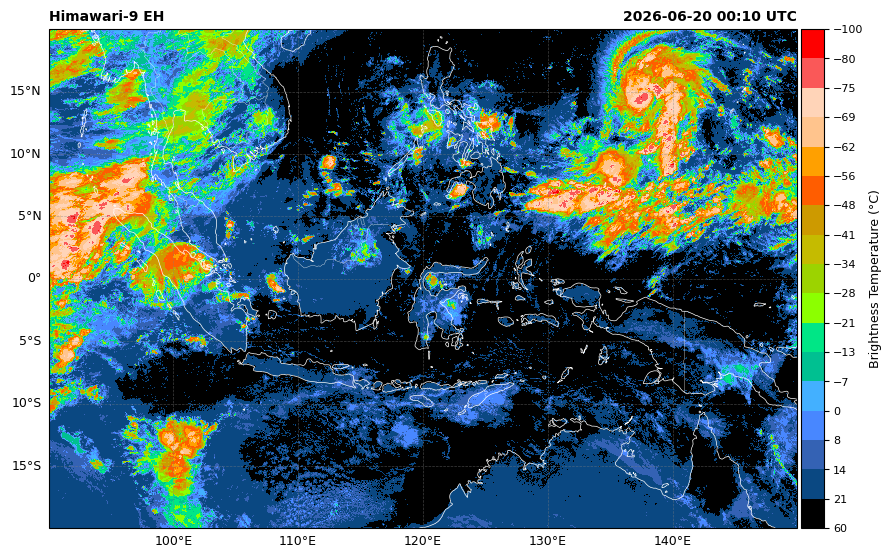

Saving plot to: gambar/H09_B13_Indonesia_20260620.Z0010.png
Saved: gambar/H09_B13_Indonesia_20260620.Z0010.png
Processing: H09_B13_Indonesia_20260620.Z0020


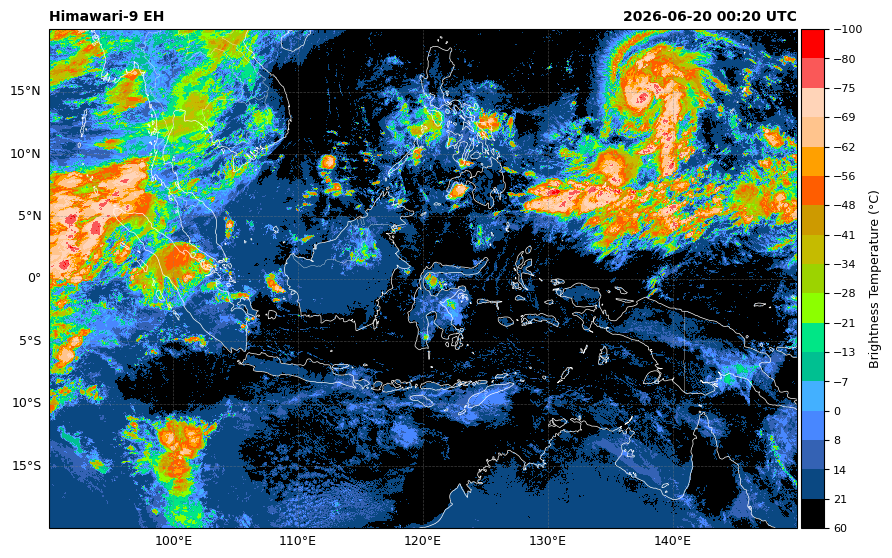

Saving plot to: gambar/H09_B13_Indonesia_20260620.Z0020.png
Saved: gambar/H09_B13_Indonesia_20260620.Z0020.png
Processing: H09_B13_Indonesia_20260620.Z0030


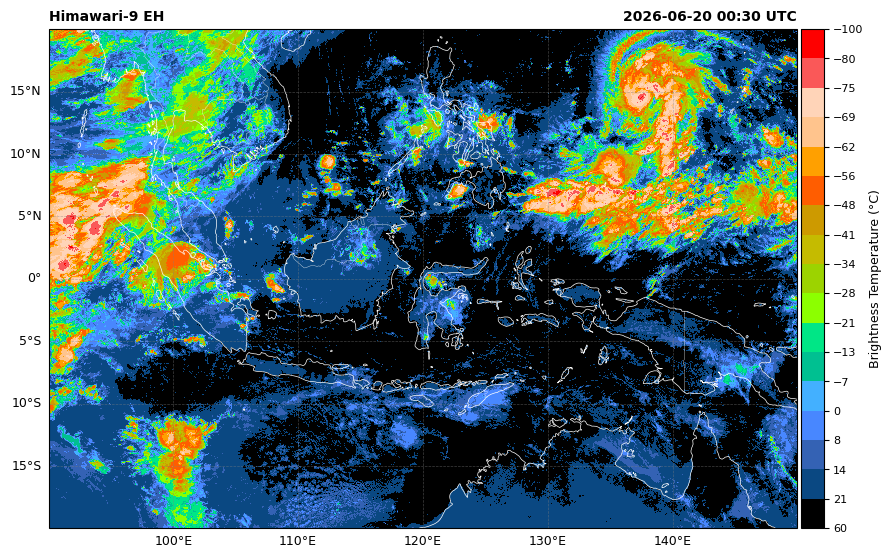

Saving plot to: gambar/H09_B13_Indonesia_20260620.Z0030.png
Saved: gambar/H09_B13_Indonesia_20260620.Z0030.png
Processing: H09_B13_Indonesia_20260620.Z0040


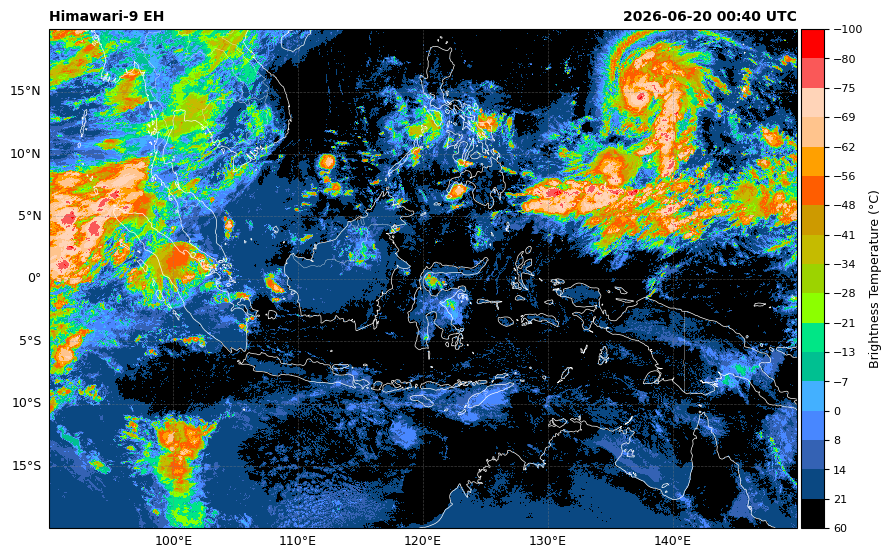

Saving plot to: gambar/H09_B13_Indonesia_20260620.Z0040.png
Saved: gambar/H09_B13_Indonesia_20260620.Z0040.png
Processing: H09_B13_Indonesia_20260620.Z0045
ERROR: data/H09_B13_Indonesia_20260620.Z0045
unpack requires a buffer of 4 bytes
Processing: H09_B13_Indonesia_20260620.Z0050


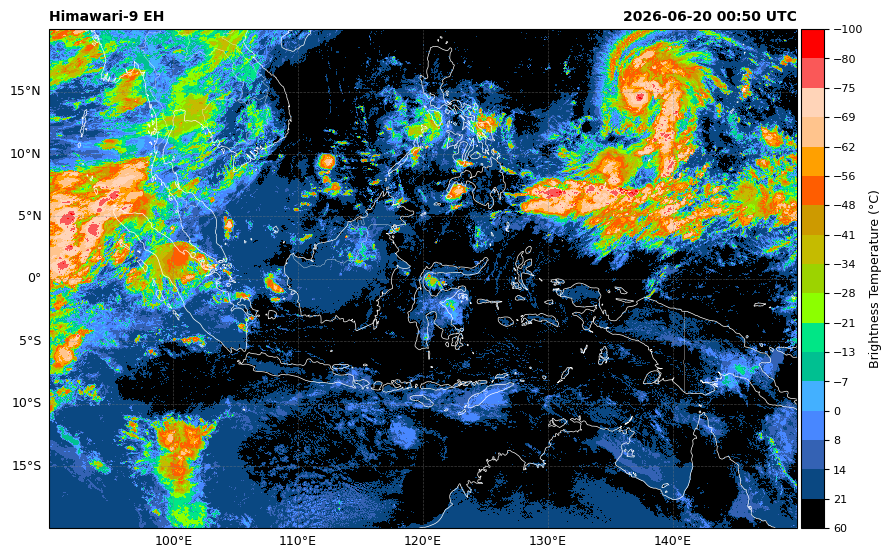

Saving plot to: gambar/H09_B13_Indonesia_20260620.Z0050.png
Saved: gambar/H09_B13_Indonesia_20260620.Z0050.png
Processing: H09_B13_Indonesia_20260620.Z0100


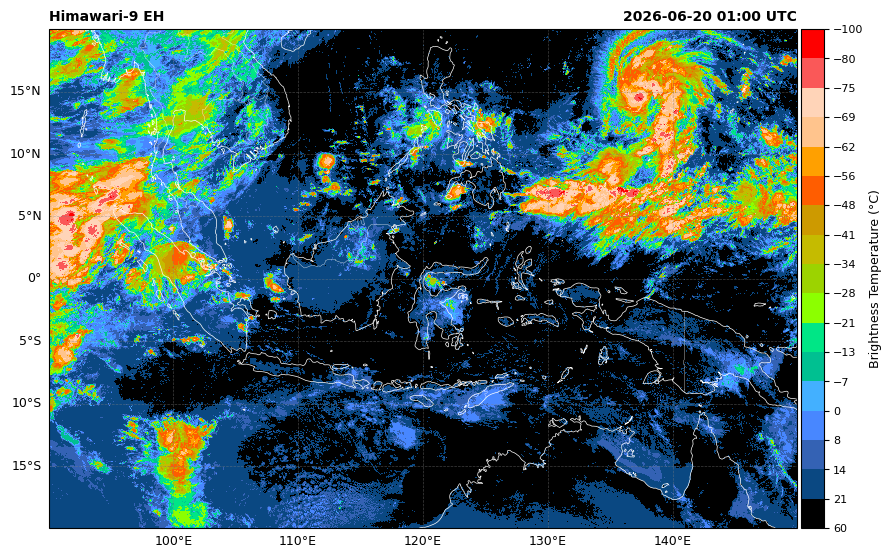

Saving plot to: gambar/H09_B13_Indonesia_20260620.Z0100.png
Saved: gambar/H09_B13_Indonesia_20260620.Z0100.png
DONE


In [20]:
def create_image(sataid_file):
    try:
        filename = os.path.basename(sataid_file)
        print("Processing:", filename)
        ds = sat.read_sataid(sataid_file)
        plt.close('all')
        a = ds.plot(cmap='EH')
        plt.title(filename)

        output_png = os.path.join(output_file,filename + '.png') #penamaan output
        ds.savefig(output_png, cmap='EH')
        #plt.savefig(
       #     output_png,
       #     dpi=150,
       #     bbox_inches='tight')
        plt.close('all')
        print("Saved:", output_png)
    except Exception as e:
        print("ERROR:", sataid_file)
        print(e)
for f in selected_files:
    create_image(f)
print("DONE")